# MNIST — Demo Notebook

### Overview
This notebook provides demonstration of the MNIST classification pipeline.
It illustrates how the models are trained, evaluated, and tested under various edge conditions.

### What’s included
-  **Quick runs** for `Random Forest`, `FNN`, and `CNN` (2 epochs by default for speed)
-  **Evaluation metrics:** accuracy, classification report, and confusion matrix
-  **Prediction examples:** correct and misclassified digits
-  **Edge-case tests:** input shape errors, dtype mismatches, NaN handling, out-of-range labels, and class imbalance

>  **Note:**
> This notebook is meant for demonstration and documentation.
> Keep training short here — full training sessions should be executed via `main.py`.

In [1]:
import os, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(" Added to sys.path:", ROOT)

def seed_everything(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'python': sys.version.split()[0], 'torch': torch.__version__, 'cuda_available': torch.cuda.is_available(), 'device': str(DEVICE)})


 Added to sys.path: C:\Users\tomaf\PycharmProjects\multimodal-ml-pipeline\Task1
{'python': '3.11.0', 'torch': '2.2.2+cpu', 'cuda_available': False, 'device': 'cpu'}


## 2. Import your module

Import the local **`mnist`** package so this demo runs on your own implementation.
Since the notebook is inside `notebooks/`, i have added the project root to `sys.path`
to make the package importable.

In [2]:
import sys
import pathlib

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Task1.mnist import models
print("Available submodules:", [n for n in dir(models) if not n.startswith("_")])
print("Successfully imported MNIST package")


C:\Users\tomaf\PycharmProjects\multimodal-ml-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available submodules: ['CNNMNIST', 'FeedForwardNNMNIST', 'RandomForestMNIST', 'cnn', 'nn', 'rf']
Successfully imported MNIST package


## 3. Data Load

I have used the custom function `load_mnist_numpy()` from the `mnist.data` module.
It returns the MNIST dataset already split into **training**, **validation**, and **test** sets —
each as NumPy arrays.

The function loads images as `(N, 28, 28)` arrays and labels as `(N,)`,
so they’re ready for both classical models (like Random Forest) and neural networks.

Below data is loading and printing the result shapes to verify everything is correct.


In [3]:

from Task1.mnist import data

X_train, y_train, X_val, y_val, X_test, y_test = data.load_mnist_numpy()
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:07<00:00, 1280242.02it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 153796.93it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1367508.55it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2264684.83it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



((54000, 28, 28), (6000, 28, 28), (10000, 28, 28), (54000,), (6000,), (10000,))

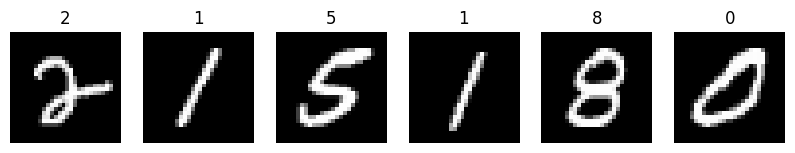

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(10,2))
for i in range(6):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(int(y_train[i]))
    axes[i].axis('off')
plt.show()

## 4. Baseline — Random Forest (flattened pixels)

Let's start with a **Random Forest** as a simple non-neural baseline.
This model operates on flattened pixel vectors — each image of shape `(28, 28)`
is reshaped into a 1D vector of length `784`.

Using the unified interface `MnistClassifier("rf")`,
i have trained the model, maked predictions on the test set, and evaluated its accuracy.


In [5]:
from Task1.mnist.facade import MnistClassifier

rf = MnistClassifier('rf')
rf.train(X_train, y_train, X_val, y_val)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print('RF test accuracy:', acc_rf)
print(classification_report(y_test, y_pred_rf))

RF test accuracy: 0.9691
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 5. FNN — short demo (2 epochs)

The **Feed-Forward Neural Network (FNN)** is a simple fully connected model
where data flows only in one direction — from input to output.
It’s implemented as a small **multi-layer perceptron (MLP)** with linear layers, activations, and a softmax output.



In [6]:

fnn = MnistClassifier('nn', epochs=2, batch_size=128, lr=1e-3, print_val=True)

fnn.train(X_train, y_train, X_val, y_val)
y_pred_fnn = fnn.predict(X_test)

acc_fnn = accuracy_score(y_test, y_pred_fnn)
print('FNN test accuracy:', acc_fnn)
print(classification_report(y_test, y_pred_fnn))


[MLP] epoch 01 | train_loss=0.3841 | val_acc=0.9427
[MLP] epoch 02 | train_loss=0.1546 | val_acc=0.9602
FNN test accuracy: 0.9634
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.96      0.97      0.96      1032
           3       0.98      0.94      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.95      0.95      0.95       974
           9       0.94      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



## 6. CNN — short demo (2 epochs)

The **Convolutional Neural Network (CNN)** is designed to capture local spatial patterns
by applying convolutional filters over the image.
Unlike FNNs, it preserves the 2D structure of the input, making it much better suited for image data.



In [7]:
cnn = MnistClassifier('cnn', epochs=2, batch_size=128, lr=1e-3, print_val=True)
cnn.train(X_train, y_train, X_val, y_val)
y_pred_cnn = cnn.predict(X_test)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
print('CNN test accuracy:', acc_cnn)
print(classification_report(y_test, y_pred_cnn))

[CNN] epoch 01 | train_loss=0.2227 | val_acc=0.9693
[CNN] epoch 02 | train_loss=0.0610 | val_acc=0.9823
CNN test accuracy: 0.9853
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.96      1.00      0.98       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 7. Confusion Matrix (CNN)

To better visualize model performance, i have ploted the **confusion matrix** for the CNN predictions.
It shows how often each digit is correctly classified versus confused with another.

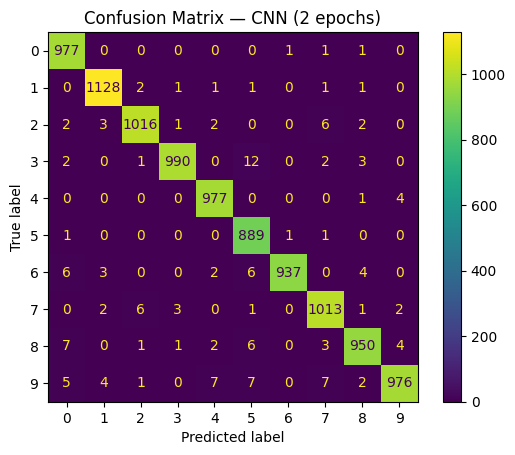

In [8]:
cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(cm)
disp.plot(values_format='d')
plt.title('Confusion Matrix — CNN (2 epochs)')
plt.show()